In [1]:
import yaml
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load nodes yaml
with open("../models/ASEAN/nodes.yaml", "r") as file:
    nodes = yaml.safe_load(file)['nodes']

# Load links yaml
with open("../models/ASEAN/links.yaml", "r") as file:
    links = yaml.safe_load(file)['links']

# Load time definitions yaml
with open("../models/ASEAN/time_definitions.yaml", "r") as file:
    time_definition = yaml.safe_load(file)['time_definition']

# Load generators yaml
with open("../models/ASEAN/generators.yaml", "r") as file:
    generators = yaml.safe_load(file)

# Load demand yaml
with open("../models/ASEAN/demand.yaml", "r") as file:
    demand = yaml.safe_load(file)['demand']

In [3]:
network = pypsa.Network()

# ---
# set time index (snapshots)
year = time_definition['year']

snapshot = (
    pd.date_range(
        start=f'{year}-01-01 00:00:00', 
        end= f'{year}-01-31 23:00:00', 
        freq='h'
    )
)

network.set_snapshots(snapshot)

# ---
# add carriers

#emissions = {'coal': 0.34, 'gas': 0.2, 'oil': 0.26, 'hydro': 0}

network.madd(
    "Carrier",
    ["coal", "gas", "nuclear", "bioenergy", "hydro", "wind", "solar"],
    #co2_emissions=emissions,
    nice_name=["coal", "gas", "nuclear", "bioenergy", "hydro", "wind", "solar"],
    color=["black", "grey", "red", "aquamarine", "dodgerblue", "orange", "yellow"],
)

# ---
# add buses (nodes)
for node in nodes:
    network.add(
        "Bus",  # PyPSA component
        node['id'], # bus name
        x = node['coords'][1], # longitude
        y = node['coords'][0] # latitude
    )

# ---
# add lines
for link in links:
    network.add(
        "Link", 
        name=link['id'],
        bus0=link['from_node'],
        bus1=link['to_node'],
        p_nom=link['initial_capacity'],
        p_nom_extendable=link['extendable'],
        carrier=link['carrier'],
        efficiency=1,
        lifetime=99,
    )

# ---
# add generators

for technology in generators:
    for bus in technology['initial_capacity'].keys():
        network.add(
            'Generator', # PyPSA component
            bus + '-' + technology['id'], # generator name
            type = technology['id'], # technology type (e.g., solar, gas-ccgt etc.)
            bus = bus, # region/bus/balancing zone
            # ---
            # unique technology parameters by bus
            p_nom = technology['initial_capacity'][bus], # starting capacity (MW)
            p_nom_extendable = technology['extendable'][bus], # can the model build more?
            capital_cost = technology['capital_cost'][bus], # currency/MW
            marginal_cost = technology['marginal_cost'][bus], # currency/MWh
            # ---
            # universal technology parameters
            carrier = technology['id'], # commodity/carrier
            lifetime = technology['lifetime'], # years
            efficiency = technology['efficiency'], # efficiency
            start_up_cost = technology['start_up_cost'], # currency/MW
            shut_down_cost = technology['shut_down_cost'], # currency/MW
            ramp_limit_up = technology['ramp_limit_up'], # per unit
            ramp_limit_down = technology['ramp_limit_up'], # per unit
            #committable = technology['committable'], # for unit commitment
        )

# ---
# add load
demand_profiles = (
    pd
    .read_csv('../data/clean/demand_profiles.csv')
    .drop('hour',axis=1)
    .iloc[0:len(network.snapshots)]
)

for bus in demand_profiles.columns:
    network.add(
        "Load", # PyPSA component
        bus, # load name
        bus=bus, # region/bus/balancing zone
        p_set=demand[0]['multiplier'][bus] * demand_profiles[bus].values # demand profile
    )

/Users/aman/miniconda3/envs/V20/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



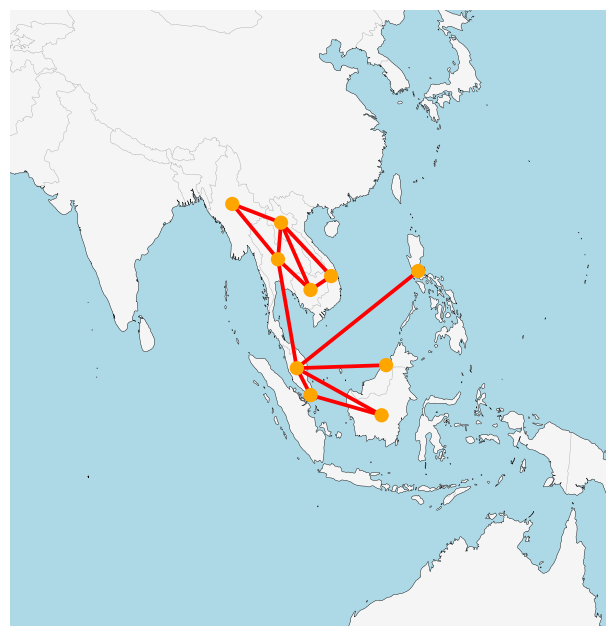

In [15]:
# ---
# plot
import cartopy.crs as ccrs

f,ax=plt.subplots(1,1,figsize=(10, 8),subplot_kw={"projection":ccrs.EqualEarth()})

# Pandas series with MultiIndex
collection = network.plot(
    bus_sizes=1,
    bus_colors='orange',
    #bus_colors={"gas": "indianred", "wind": "midnightblue"},
    margin=1.,
    #flow=flow,
    line_widths=0,
    line_colors='red',
    link_widths=2.7,
    link_colors='red',
    #projection=ccrs.EqualEarth(),
    color_geomap=True,
    ax=ax,
)


In [ ]:
demand[0]['multiplier'][bus]

In [ ]:
network.optimize(solver_name='highs')

In [ ]:
network.objective / 1e9

In [ ]:
(network.statistics.capex() + network.statistics.opex()).div(1e6)

In [ ]:
df = ( network
 .generators
 .groupby(['type','bus'])
 .sum(numeric_only=True)
 .p_nom
 .div(1e3)
 .reset_index()
 .pivot_table(index='bus',columns='type',values='p_nom', aggfunc='sum')
)

df.plot(
    kind='bar', 
    stacked=True, 
    color=df.columns.map(network.carriers.color),
    edgecolor='black',
) 

In [ ]:
network.loads_t.p_set.plot(figsize=(8, 5), ylabel="MW")

In [ ]:
def plot_dispatch(n, time="2022-01"):
    p_by_carrier = n.generators_t.p.groupby(n.generators.type, axis=1).sum().div(1e3)

    if not n.storage_units.empty:
        sto = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T.div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(8,5))

    color = p_by_carrier.columns.map(n.carriers.color)

    p_by_carrier.where(p_by_carrier > 0).iloc[0:24*10].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )

    charge = p_by_carrier.where(p_by_carrier < 0).dropna(how="all", axis=1).loc[time]

    if not charge.empty:
        charge.plot.area(
            ax=ax,
            linewidth=0,
            #color=charge.columns.map(n.carriers.color),
        )

    n.loads_t.p_set.sum(axis=1).iloc[0:24*10].div(1e3).plot(ax=ax, c="k")

    plt.legend(loc=(1.05, 0))
    ax.set_ylabel("GW")
    #ax.set_ylim(-200, 200)

plot_dispatch(network)

In [ ]:
# ---
# plot
import cartopy.crs as ccrs

s = network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.type]).sum()
flow = pd.Series(10, index=network.branches().index)

f,ax=plt.subplots(1,1,figsize=(10, 8),subplot_kw={"projection":ccrs.EqualEarth()})

# Pandas series with MultiIndex
collection = network.plot(
    bus_sizes=s / 1e4,
    #bus_colors={"gas": "indianred", "wind": "midnightblue"},
    margin=0.5,
    flow=flow,
    line_widths=0,
    link_widths=2.7,
    #projection=ccrs.EqualEarth(),
    color_geomap=True,
    line_colors=network.lines_t.p0.mean().abs(),
    ax=ax,
)

plt.colorbar(collection[2], fraction=0.04, pad=0.004, label="Flow in MW")
plt.show()

In [ ]:
s = network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.type]).sum()

In [ ]:
network.generators['p_nom_opt'].reset_index()

In [ ]:
network.generators_t.p.to_exc('generators_t.csv')

In [ ]:
# asean_country_iso = ['IDN', 'MYS', 'PHL', 'SGP', 'THA', 'VNM', 'BRN', 'KHM', 'LAO', 'MMR']

# df = ( pd
#  .read_csv('../data/clean/ember-electricity-data.csv', sep=',')
# )

# ( df
#  .loc[ df['Country code'].isin(asean_country_iso)]
#  .query('Year == 2022')
#  .query('Category == "Capacity"')
#  .query('Subcategory == "Fuel"')
#  .pivot_table(index='Country code', columns='Variable', values='Value', aggfunc='sum')
#  .mul(1000)
# )